In [37]:
!pip install tensorflow


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

#Load dataset 
file_path = ('customer_churn_nn.csv')
df = pd.read_csv(file_path)
print(df.head())




  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1   

In [39]:
print('Shape of dataset:', df.shape)

Shape of dataset: (2000, 17)


In [40]:
print(df.dtypes)

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [41]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [42]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

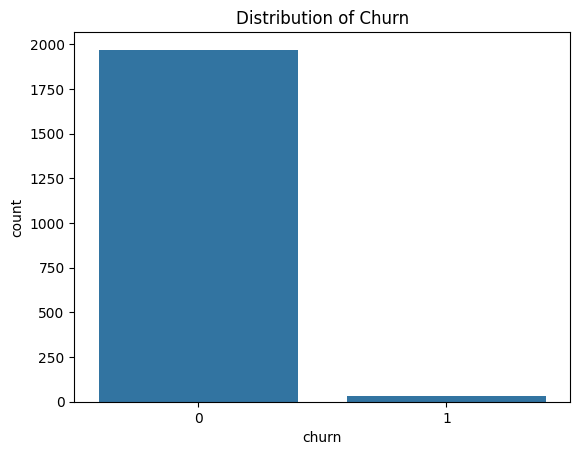

In [43]:
sns.countplot(x='churn', data=df)
plt.title('Distribution of Churn')
plt.show()

In [44]:
# Data Preprocessing

# customer_id is not useful for prediction
df = df.drop('customer_id', axis=1)

label_encoder = LabelEncoder()

categorical_cols =['region', 'plan_type', 'contract_type', 'payment_method']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col]) 

Neural networks work only with numbers.So categorical text values are converted into numeric values.

In [45]:
X = df.drop('churn', axis=1)
y = df['churn']

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature scaling improves neural network performance. It makes all values lie on a similar scale

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
# Neural Network Model Building

model = Sequential()

#input + hidden layer
model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))

#second Hidden layer
model.add(Dense(8, activation='relu'))

#Output layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Training and Evaluation

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20


40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8070 - loss: 0.5633 - val_accuracy: 0.9406 - val_loss: 0.4620
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9773 - loss: 0.3745 - val_accuracy: 0.9781 - val_loss: 0.3136
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.2443 - val_accuracy: 0.9781 - val_loss: 0.2140
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9867 - loss: 0.1639 - val_accuracy: 0.9781 - val_loss: 0.1584
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.1212 - val_accuracy: 0.9781 - val_loss: 0.1317
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9867 - loss: 0.0992 - val_accuracy: 0.9781 - val_loss: 0.1183
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.0874 - val_accuracy: 0.9781 - val_loss: 0.1114
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9867 - loss: 0.0805 - val_accuracy: 0.9781 - val_loss: 0

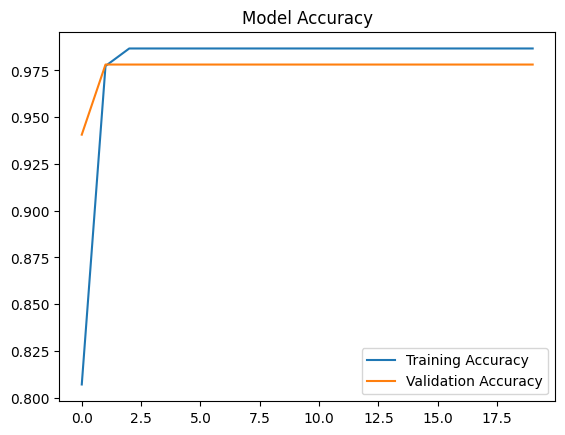

In [52]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

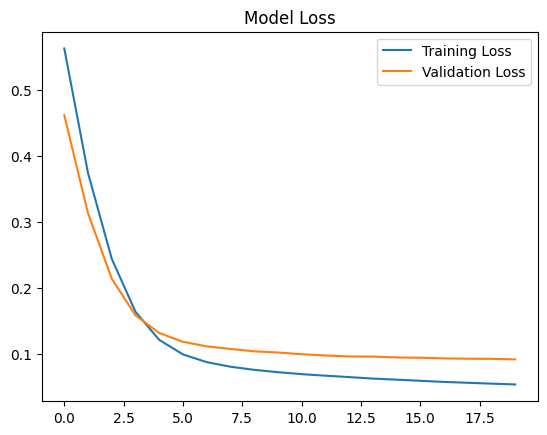

In [53]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [54]:
loss, accuracy = model.evaluate(X_test, y_test)

print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9825 - loss: 0.0755
Test Loss: 0.07545870542526245
Test Accuracy: 0.9825000166893005


In [55]:
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


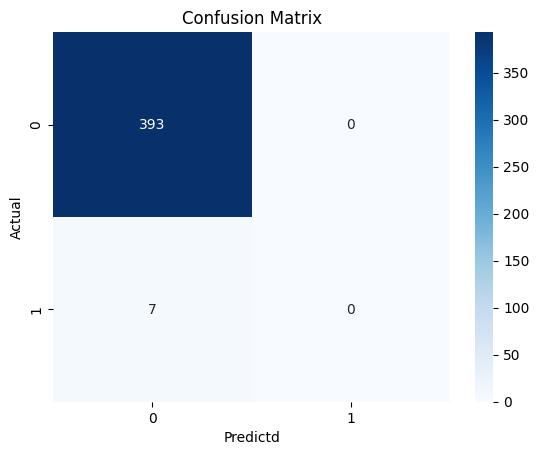

In [56]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predictd')
plt.ylabel('Actual')
plt.show()

In [57]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classificatio

### Brief Explaination of the result 

The neural network model performed well on the dataset with good training and testing accuracy.
The loss decreased gradually during training, indicating effective learning.
The confusion matrix showed that most predictions were correctly classified.
A small difference between training and testing accuracy suggests minimal overfitting




In [58]:
# Hyperparameter Experimentation 

model = Sequential()
model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [60]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.9688 - loss: 0.3413 - val_accuracy: 0.9781 - val_loss: 0.2196
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9867 - loss: 0.1364 - val_accuracy: 0.9781 - val_loss: 0.1260
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9867 - loss: 0.0849 - val_accuracy: 0.9781 - val_loss: 0.1071
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9867 - loss: 0.0721 - val_accuracy: 0.9781 - val_loss: 0.1026
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9867 - loss: 0.0667 - val_accuracy: 0.9781 - val_loss: 0.1003
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9867 - loss: 0.0632 - val_accuracy: 0.9781 - val_loss: 0.0992
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9867 - loss: 0.0606 - val_accuracy: 0.9781 - val_loss: 0.0987
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9867 - loss: 0.0582 - val_accuracy: 0.9781 - 

# Final Reflection 

1. Role of Weights and Biases 
Weights help the model learn the importance of features.Bias helps shift activation values for better learning.

2. Why Activation Function is Required
Activation functions introduce non-linearity. Without them, neural networks behave like linear models.

3. Effect of Learning Rate
-> Very high learning rate causes unstable learning.
-> Very low learning rate makes training very slow.

4. Underfitting vs Overfitting
-> Underfitting happens when the model learns too little.'
-> Overfitting happens when the model memorizes training data.